# ST quality control — worked example

Computes the six per-section QC features of Shulman et al., *Cell* 2026 on one
spatial-transcriptomics section, using the functions in `../lib/`.

**Histological image quality** (per H&E tile, averaged over the section)
1. Hematoxylin intensity — mean hematoxylin OD (HED-deconvolved) within tissue
2. Eosin intensity — mean eosin OD within tissue
3. Image sharpness — variance of the Laplacian of the grayscale tile

**Gene-expression quality** (per spot, averaged over the section)
4. Mean total UMI counts per spot
5. Mean mitochondrial counts per spot (log1p)
6. Mean hemoglobin counts per spot (log1p)

Example section: **NCBI776** — a breast-cancer Visium section from the public
HEST-1k dataset ([MahmoodLab/hest](https://huggingface.co/datasets/MahmoodLab/hest)),
one of the HEST sections retained by paper QC. 200 raw H&E tiles and the raw
count matrix are in `../data/example/`. Image QC follows the paper: the first
step is Macenko stain normalization, after which the three image metrics are
computed with scikit-image; expression QC uses `scanpy.pp.calculate_qc_metrics`.


## Setup

In [1]:
import sys; sys.path.insert(0, "../lib")
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings("ignore")

from stain_norm import macenko_normalizer
from qc_metrics import (compute_image_qc, image_qc_per_section,
                        compute_expression_qc, THRESHOLDS, passes_qc)


## Load the example section

In [2]:
ex = np.load("../data/example/NCBI776_he_tiles.npz")
tiles = ex["tiles"]          # (200, 224, 224, 3) uint8 H&E tiles
adata = sc.read_h5ad("../data/example/NCBI776_counts.h5ad")   # raw counts
print(f"{tiles.shape[0]} H&E tiles of {tiles.shape[1]}x{tiles.shape[2]} px")
print(f"expression: {adata.n_obs} spots x {adata.n_vars} genes")

200 H&E tiles of 224x224 px
expression: 4992 spots x 18056 genes


## Histological image quality

The bundled tiles are **raw**, so the first step is Macenko stain normalization
(`macenko_normalizer().transform`). The three image metrics are then computed on
the normalized tiles and averaged over the section.


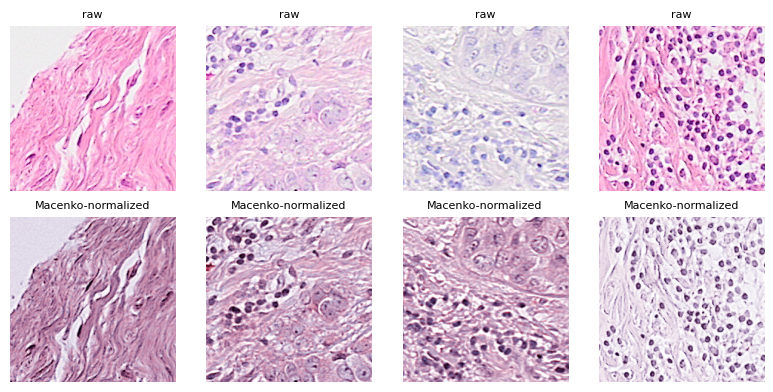

In [3]:
normalizer = macenko_normalizer()
tiles_norm = np.stack([normalizer.transform(t) for t in tiles])

fig, axes = plt.subplots(2, 4, figsize=(8, 4))
for j in range(4):
    axes[0, j].imshow(tiles[j]);      axes[0, j].set_title("raw", fontsize=8)
    axes[1, j].imshow(tiles_norm[j]); axes[1, j].set_title("Macenko-normalized", fontsize=8)
for ax in axes.ravel():
    ax.axis("off")
fig.tight_layout(); plt.show()


In [4]:
image_qc = image_qc_per_section(tiles_norm)
for k, v in image_qc.items():
    print(f"  {k:<12} {v:.6f}")

  hematoxylin  0.041779
  eosin        0.020204
  sharpness    0.034257


## Gene-expression quality

`compute_expression_qc` flags mitochondrial (`MT-*`) and hemoglobin genes and
runs `scanpy.pp.calculate_qc_metrics` on the raw counts, then averages the
per-spot values over the section.

In [5]:
expression_qc = compute_expression_qc(adata)
for k, v in expression_qc.items():
    print(f"  {k:<24} {v:.4f}")

  total_counts             23096.5160
  log1p_total_counts_mt    6.2788
  log1p_total_counts_hb    0.1544


## The six QC features vs the paper thresholds

`THRESHOLDS` holds the paper's per-metric cutoffs; `passes_qc` flags whether a
value falls on the passing side.

In [6]:
metrics = {**image_qc, **expression_qc}
flags = passes_qc(metrics)

def thr_str(name):
    t = THRESHOLDS[name]
    return " / ".join(f"{k}={v:g}" for k, v in t.items())

summary = pd.DataFrame({
    "value":     {k: round(v, 6) for k, v in metrics.items()},
    "threshold": {k: thr_str(k) for k in metrics},
    "passes":    flags,
})
summary

,value,threshold,passes
hematoxylin,0.041779,max=0.053546 / min=0.029768,True
eosin,0.020204,max=0.022495 / min=0.017486,True
sharpness,0.034257,min=0.000637,True
total_counts,23096.516026,min=6193.7,True
log1p_total_counts_mt,6.278775,max=8.3603,True
log1p_total_counts_hb,0.154395,max=0.7355,True
